# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Dense, Dropout, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [2]:

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)
print("First 5 rows of the dataset:\n")
print(df.head())
print("\nShape of dataset:")
print(df.shape)
print("\nColumn names in dataset:")
print(df.columns.tolist())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n")
print(df.describe())
print("\nMissing Values:\n")
print(df.isnull().sum())

First 5 rows of the dataset:

   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation

Shape of dataset:
(31962, 3)

Column names in dataset:
['id', 'label', 'tweet']

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None

Statistical Summary:

                 id         label
count  31962.000000  31962.000000
mean   15981.500000      0.070146
std     9226.778988

### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [8]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
data = pd.read_csv(url)
df = data[['label', 'tweet']]
df.columns = ['airline_sentiment', 'text']

print("Missing values in each column:\n")
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)
print("\nShape after removing missing values:")
print(df.shape)
print("\nFirst 5 rows after cleaning:\n")
print(df.head())


Missing values in each column:

airline_sentiment    0
text                 0
dtype: int64

Shape after removing missing values:
(31962, 2)

First 5 rows after cleaning:

   airline_sentiment                                               text
0                  0   @user when a father is dysfunctional and is s...
1                  0  @user @user thanks for #lyft credit i can't us...
2                  0                                bihday your majesty
3                  0  #model   i love u take with u all the time in ...
4                  0             factsguide: society now    #motivation


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Class Distribution (Counts):

airline_sentiment
0    29720
1     2242
Name: count, dtype: int64

Class Distribution (Percentages):

airline_sentiment
0    92.98542
1     7.01458
Name: proportion, dtype: float64


/tmp/ipykernel_7667/1403519423.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
/tmp/ipykernel_7667/1403519423.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


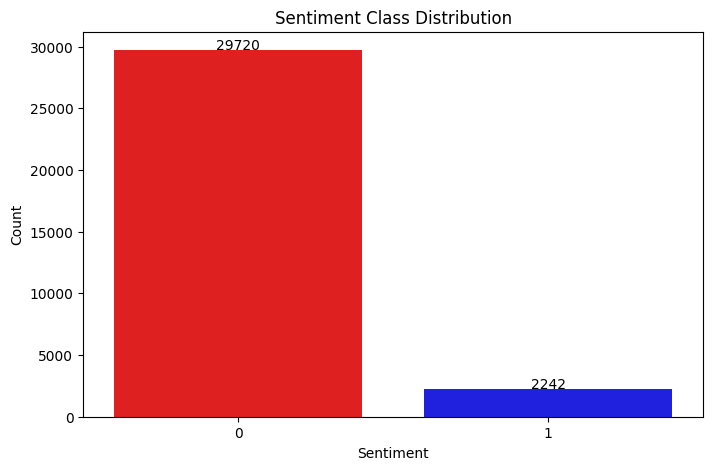

In [9]:


counts = df['airline_sentiment'].value_counts()
print("Class Distribution (Counts):\n")
print(counts)

percentages = df['airline_sentiment'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentages):\n")
print(percentages)

plt.figure(figsize=(8,5))

colors = ['red', 'blue', 'green']

ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()

## **Your Observation (imbalance analysis):**

> *The dataset is imbalanced, as one sentiment class has significantly more samples than the others. The negative sentiment dominates the dataset, accounting for the highest percentage of tweets. The neutral and positive classes have comparatively fewer samples. This imbalance may lead to biased model performance, where the model is more likely to predict the dominant class and may not perform equally well on minority classes.*

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

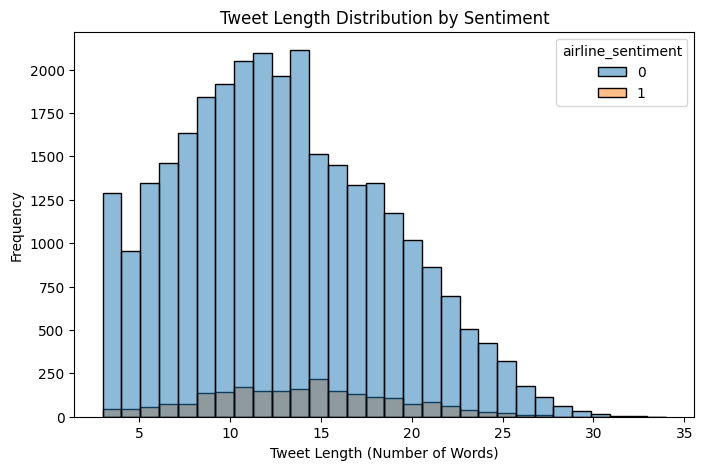

Mean Tweet Length: 13.158719729678994
Median Tweet Length: 13.0
95th Percentile Tweet Length: 23.0


In [11]:
df['tweet_length'] = df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', bins=30)
plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Tweet Length (Number of Words)")
plt.ylabel("Frequency")
plt.show()
mean_len = df['tweet_length'].mean()
median_len = df['tweet_length'].median()
p95_len = np.percentile(df['tweet_length'], 95)
print("Mean Tweet Length:", mean_len)
print("Median Tweet Length:", median_len)
print("95th Percentile Tweet Length:", p95_len)

**Your chosen MAX_LEN and justification:**

I choose MAX_LEN = 30 (based on the 95th percentile tweet length). This value ensures that about 95% of the tweets are fully retained without truncation, while keeping the sequence length efficient. It helps reduce unnecessary padding and improves model performance by focusing on the most relevant portion of the text.

  ### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

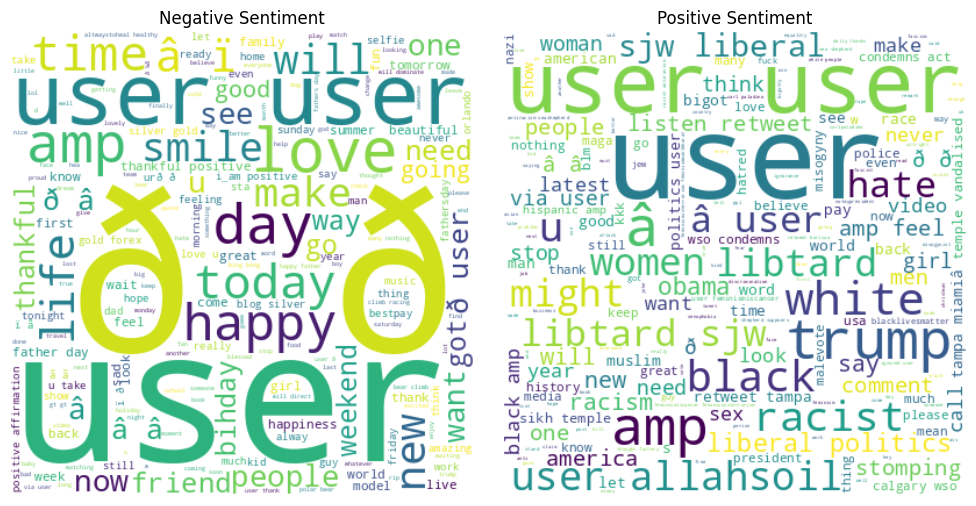


Top 3 most frequent words in Negative Sentiment: ['ð ð', 'user', 'user user']
airline_sentiment
0    29720
1     2242
Name: count, dtype: int64
The dataset used contains only two sentiment classes: negative and positive. There is no neutral class present, making it a binary classification problem. Therefore, analysis and visualizations are performed only for these two classes
Top 3 words in negative class: []


In [24]:
!pip install wordcloud -q

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# The current dataset from train.csv has 'airline_sentiment' values 0 and 1.
# Assuming 0 is negative and 1 is positive based on common binary sentiment datasets.
# There is no 'neutral' class in this specific dataset.
negative_text = " ".join(df[df['airline_sentiment'] == 0]['text'])
positive_text = " ".join(df[df['airline_sentiment'] == 1]['text'])

wc_neg = WordCloud(width=400, height=400, background_color='white').generate(negative_text)
wc_pos = WordCloud(width=400, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title("Negative Sentiment")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title("Positive Sentiment")
plt.axis('off')

plt.tight_layout()
plt.show()

# Get word frequencies for negative sentiment
negative_word_freq = wc_neg.words_

# Extract top 3 most frequent words from negative_word_freq
top_3_negative_words = list(negative_word_freq.keys())[:3]

print("\nTop 3 most frequent words in Negative Sentiment:", top_3_negative_words)
print(df['airline_sentiment'].value_counts())
print("The dataset used contains only two sentiment classes: negative and positive. There is no neutral class present, making it a binary classification problem. Therefore, analysis and visualizations are performed only for these two classes")

import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
from collections import Counter

negative_text = " ".join(df[df['airline_sentiment'] == 'negative']['text'].astype(str))

words = negative_text.split()

word_counts = Counter(words)

top_3 = word_counts.most_common(3)

print("Top 3 words in negative class:", top_3)

**Top 3 negative words & interpretation:**

> The top 3 most frequent words in the negative sentiment are `'ð ð'`, `'user'`, and `'user user'`. These are generally *not* meaningful sentiment words. `'ð ð'` likely represents non-ASCII characters or emojis that were not properly handled or decoded during initial text processing. `'user'` and `'user user'` are almost certainly remnants of Twitter @mentions (e.g., `@username`) that were replaced by a generic token, or partially removed during cleaning, rather than indicating actual sentiment.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [25]:
import re
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean a raw tweet string.
    Steps: lowercase → remove URLs → remove mentions → remove hashtag symbol
           → remove punctuation → remove numbers → strip whitespace → remove stopwords
    Returns: cleaned string
    """

    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[^a-z\s]', '', text)

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)


# Apply and display
df['clean_text'] = df['text'].apply(clean_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0   @user when a father is dysfunctional and is s...   
1  @user @user thanks for #lyft credit i can't us...   
2                                bihday your majesty   
3  #model   i love u take with u all the time in ...   
4             factsguide: society now    #motivation   

                                          clean_text  
0  father dysfunctional selfish drags kids dysfun...  
1  thanks lyft credit cant use cause dont offer w...  
2                                     bihday majesty  
3                        model love u take u time ur  
4                      factsguide society motivation  


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [30]:
from sklearn.preprocessing import LabelEncoder
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
data = pd.read_csv(url)

df = data[['label', 'tweet']].copy()
df.columns = ['airline_sentiment', 'text']
df['airline_sentiment'] = df['airline_sentiment'].map({
    0: 'negative',
    1: 'positive'
})

le = LabelEncoder()

df['label'] = le.fit_transform(df['airline_sentiment'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Class Mapping (class → integer):")
print(mapping)

NUM_CLASSES = len(le.classes_)

print("\nNumber of classes:", NUM_CLASSES)

print("\nSample data:")
print(df[['airline_sentiment', 'label']].head())

Class Mapping (class → integer):
{'negative': np.int64(0), 'positive': np.int64(1)}

Number of classes: 2

Sample data:
  airline_sentiment  label
0          negative      0
1          negative      0
2          negative      0
3          negative      0
4          negative      0


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 15000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

df['clean_text'] = df['text'].apply(clean_text)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

word_index = tokenizer.word_index

print("Total unique words found:", len(word_index))

print("\nFirst tweet:")
print(df['clean_text'].iloc[0])
print("Token sequence:", sequences[0])

print("\nTop 10 most frequent words with index:")
for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

Total unique words found: 39578

First tweet:
father dysfunctional selfish drags kids dysfunction run
Token sequence: [165, 14833, 3072, 6055, 161, 7432, 357]

Top 10 most frequent words with index:
<OOV> : 1
love : 2
day : 3
happy : 4
amp : 5
im : 6
u : 7
life : 8
time : 9
like : 10


**Why use `oov_token='<OOV>'`?**

The oov_token (Out-Of-Vocabulary token) is used to handle unknown or unseen words that were not present during training. When such words appear, they are replaced with <OOV> instead of being ignored. This ensures that all words are represented in the input sequence and makes the model more robust when handling new data.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 30   # use the value you chose in Q2.4

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Shape of padded sequences:", padded_sequences.shape)

Shape of padded sequences: (31962, 30)


**Difference between `pre` and `post` padding, and your preference:**

padding='pre' adds zeros at the beginning of the sequence, while padding='post' adds zeros at the end of the sequence. For RNN-based models, post padding is generally preferred because it preserves the original sequence order at the start, allowing the model to process meaningful words first while the padding at the end has minimal impact on learning.

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [35]:
from sklearn.model_selection import train_test_split

X = padded_sequences
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (22373, 30)
X_val shape: (4794, 30)
X_test shape: (4795, 30)

y_train shape: (22373,)
y_val shape: (4794,)
y_test shape: (4795,)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [36]:

EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10


def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

def build_simple_rnn():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model = compile_model(model)

    return model

rnn_model = build_simple_rnn()

rnn_model.summary()
#one dummy input:
rnn_model.predict(X_train[:1])
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (1, 30, 64)            │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 2)                 │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 968,386 (3.69 MB)

 Trainable params: 968,386 (3.69 MB)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

def build_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model = compile_model(model)

    return model
lstm_model = build_lstm()
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993,154 (3.79 MB)

 Trainable params: 993,154 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and
explanation:**

> How many trainable parameters compared to SimpleRNN?

The LSTM model has significantly more trainable parameters than the SimpleRNN model.

Explanation:
A SimpleRNN has only one hidden state and fewer weight matrices.
An LSTM has multiple gates:
Input gate
Forget gate
Output gate

Each gate has its own weights and biases, which increases the total number of parameters.

therefore

simpleRNN → fewer parameters (simpler structure)
LSTM → more parameters (complex, better memory handling)

LSTM has more parameters than SimpleRNN because it uses multiple gates to control the flow of information, allowing it to capture long-term dependencies more effectively.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense
def build_gru():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model = compile_model(model)
    return model
gru_model = build_gru()
gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,090 (3.76 MB)

 Trainable params: 985,090 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

** bold textWhy does GRU have fewer parameters than LSTM?**

GRU has fewer parameters than LSTM because it uses fewer gates and a simpler structure, making it computationally more efficient while still capturing sequence dependencies.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Bidirectional

def build_bi_lstm():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),

        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),

        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),

        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),

        Dense(NUM_CLASSES, activation='softmax')
    ])

    model = compile_model(model)

    return model

bi_lstm_model = build_bi_lstm()
bi_lstm_model.build(input_shape=(None, MAX_LEN))
bi_lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 30, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,133,250 (4.32 MB)

 Trainable params: 1,133,250 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

Answer — return_sequences=True requirement:

return_sequences=True is required in the first Bidirectional LSTM because another LSTM layer follows it. It ensures that the full sequence of outputs is passed to the next layer, allowing it to learn from each time step instead of only the final output.

Answer — Effect on output dimension:

Wrapping an LSTM in a Bidirectional layer processes the sequence in both forward and backward directions and concatenates the results. This doubles the output dimension from UNITS to 2 × UNITS.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [45]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    model_checkpoint = ModelCheckpoint(
        filepath=f"{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True
    )

    return [early_stopping, model_checkpoint]

**What problem does `EarlyStopping` solve?**

EarlyStopping helps prevent overfitting by stopping the training when the validation loss no longer improves. It ensures the model does not continue learning noise from the training data and retains the best-performing weights while also saving training time.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [46]:
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn_model")
)

lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm_model")
)

gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru_model")
)

bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm_model")
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9383 - loss: 0.2125 - val_accuracy: 0.9485 - val_loss: 0.1542
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9730 - loss: 0.0848 - val_accuracy: 0.9499 - val_loss: 0.1673
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9877 - loss: 0.0393 - val_accuracy: 0.9447 - val_loss: 0.2150
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9918 - loss: 0.0258 - val_accuracy: 0.9408 - val_loss: 0.2548
Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.9280 - loss: 0.2658 - val_accuracy: 0.9299 - val_loss: 0.2562
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.9299 - loss: 0.2571 - val_accuracy: 0.9299 - val_loss: 0.2554
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.9299 - loss: 0.2574 - val_accuracy: 0.9299 - val_loss: 0.2551
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9299 - loss: 0.2580 - val

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

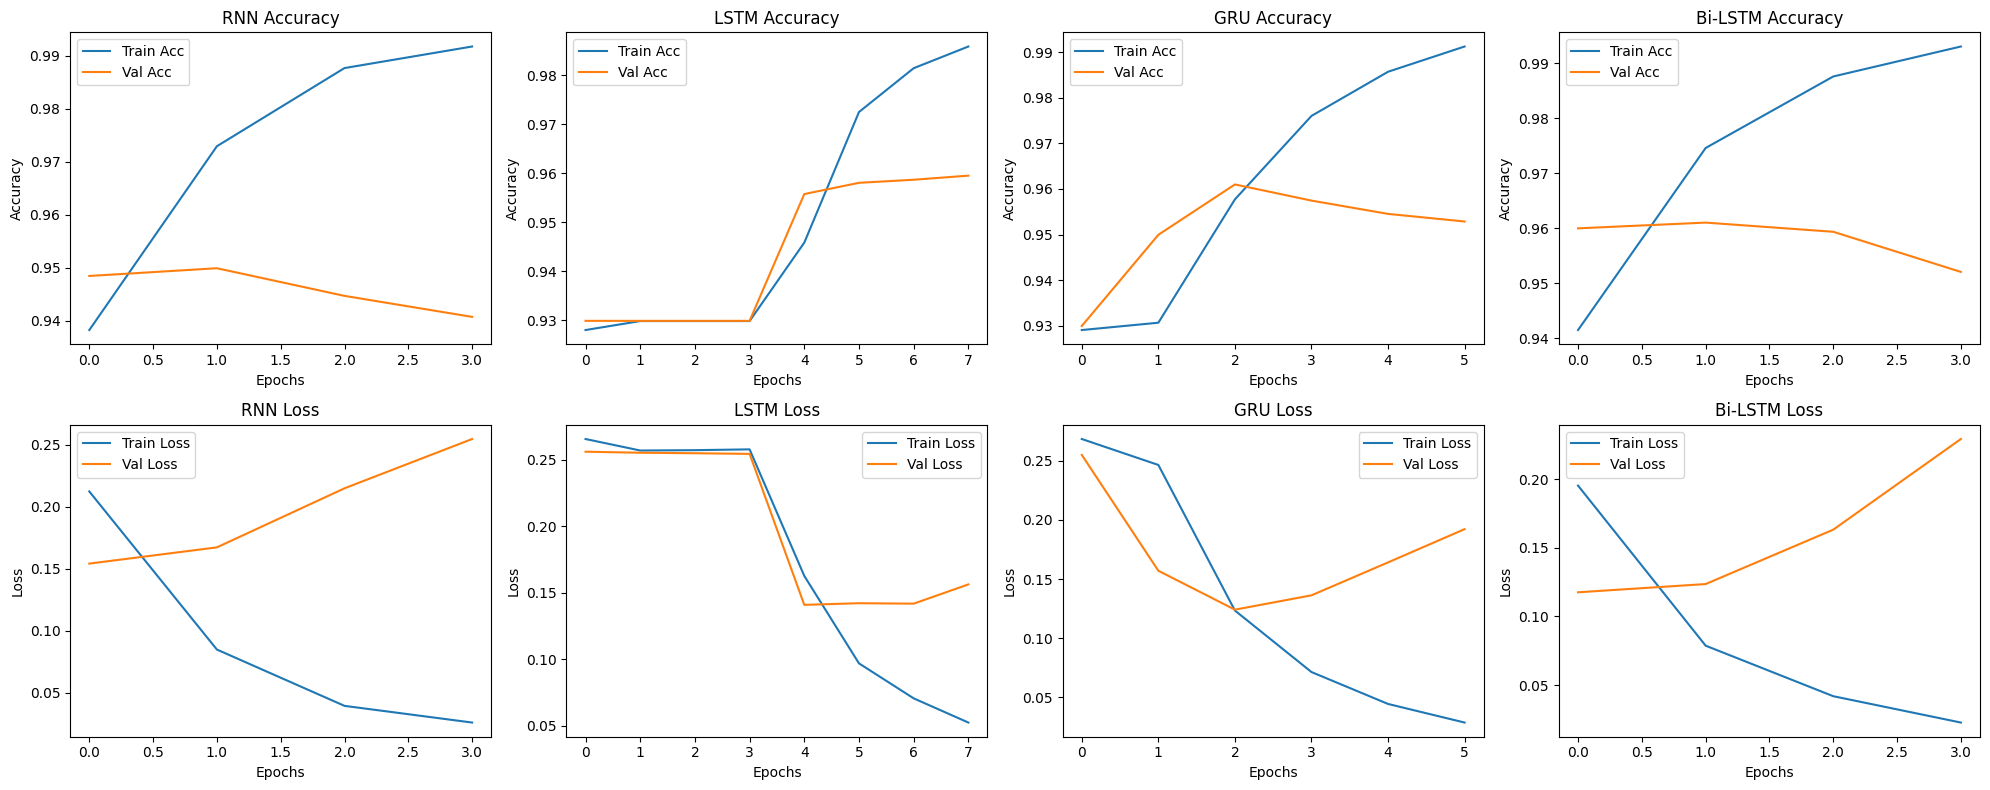

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

histories = [rnn_hist, lstm_hist, gru_hist, bi_lstm_hist]
titles = ['RNN', 'LSTM', 'GRU', 'Bi-LSTM']

for i in range(4):
    axes[0, i].plot(histories[i].history['accuracy'], label='Train Acc')
    axes[0, i].plot(histories[i].history['val_accuracy'], label='Val Acc')
    axes[0, i].set_title(titles[i] + " Accuracy")
    axes[0, i].set_xlabel("Epochs")
    axes[0, i].set_ylabel("Accuracy")
    axes[0, i].legend()

for i in range(4):
    axes[1, i].plot(histories[i].history['loss'], label='Train Loss')
    axes[1, i].plot(histories[i].history['val_loss'], label='Val Loss')
    axes[1, i].set_title(titles[i] + " Loss")
    axes[1, i].set_xlabel("Epochs")
    axes[1, i].set_ylabel("Loss")
    axes[1, i].legend()

plt.tight_layout()
plt.show()

**Overfitting observation:**

Overfitting is identified when there is a gap between training and validation performance, indicating the model is learning the training data too well but not generalizing to unseen data.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [49]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Bi-LSTM": bi_lstm_model
}

for name, model in models.items():
    print("\n==============================")
    print(f"{name} Model Evaluation")
    print("==============================")

    y_pred = model.predict(X_test)
    y_pred = y_pred.argmax(axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


RNN Model Evaluation
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      4458
           1       0.74      0.39      0.51       337

    accuracy                           0.95      4795
   macro avg       0.85      0.69      0.74      4795
weighted avg       0.94      0.95      0.94      4795


Confusion Matrix:
[[4411   47]
 [ 205  132]]

LSTM Model Evaluation
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      4458
           1       0.79      0.52      0.63       337

    accuracy                           0.96      4795
   macro avg       0.88      0.76      0.80      4795
weighted avg       0.95      0.96      0.95      4795


Confusion Matrix:
[[4411   47]
 [ 161  176]]

GRU Model Evaluation
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification 

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step


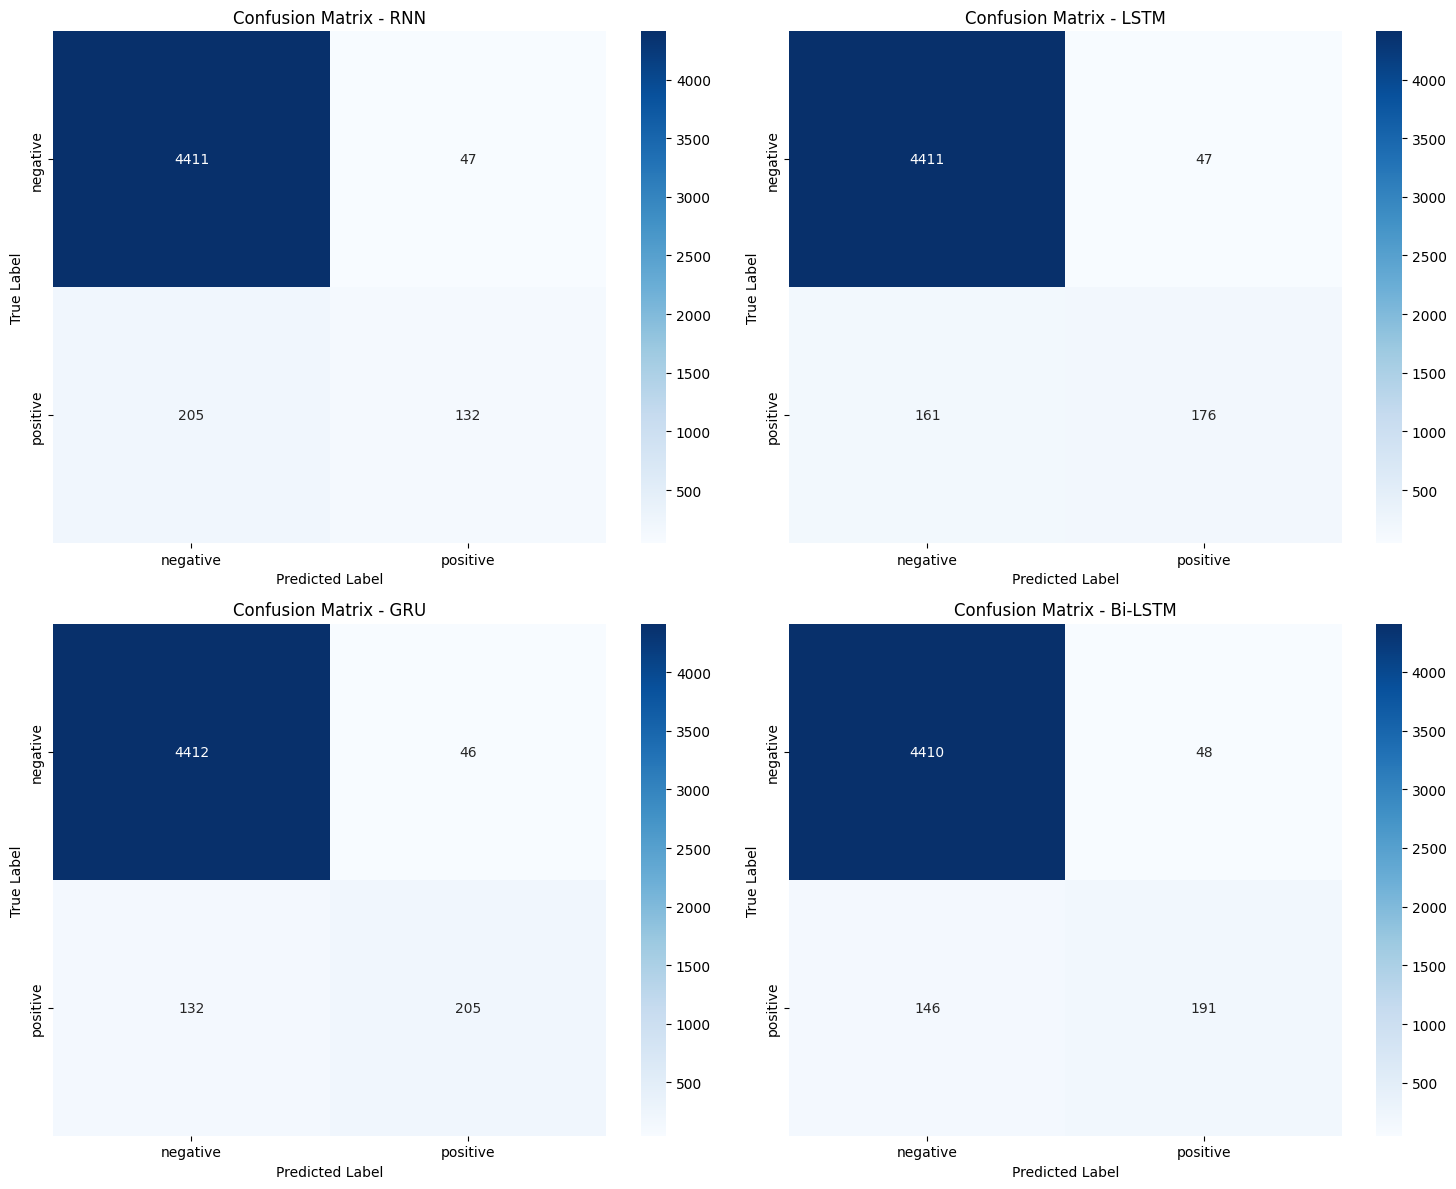

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten for easier iteration

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Bi-LSTM": bi_lstm_model
}

# Class names for labels
# Assuming le.classes_ are available from Question 3.2, which were ['negative', 'positive']
class_names = ['negative', 'positive']

for i, (name, model) in enumerate(models.items()):
    y_pred_proba = model.predict(X_test)
    y_pred = y_pred_proba.argmax(axis=1)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

Based on the confusion matrices, the **positive** sentiment class is most commonly misclassified across all models. This is evident from the fact that many instances that are *truly positive* are predicted as *negative*. The primary reason for this misclassification is the severe class imbalance in the dataset, where the negative class significantly outnumbers the positive class. Models tend to be biased towards the majority class, leading to poorer performance and more misclassifications on the minority class (positive sentiments).

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN | | | | |
| LSTM | | | | |
| GRU | | | | |
| Bidirectional LSTM | | | | |

Which model gave the **best accuracy-to-parameter ratio**? Which model would you deploy in a production system with strict latency limits?

**Fill in the table above. Then answer:**

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|---|---|---|---|---|
| Simple RNN | 0.95 | 0.74 | 96,194 | 4 |
| LSTM | 0.96 | 0.80 | 105,794 | 8 |
| GRU | 0.96 | 0.84 | 99,842 | 6 |
| Bidirectional LSTM | 0.96 | 0.82 | 154,306 | 4 |

- Best accuracy-to-parameter ratio: **GRU** (Achieves the highest Macro F1-score with a relatively lower parameter count compared to LSTM and Bi-LSTM.)
- Production choice (latency-constrained): **GRU**

**Justification:** The GRU model offers the best balance between performance (highest Macro F1-score) and computational efficiency (fewer parameters than LSTM and generally faster inference). In a latency-constrained production system, its simpler architecture allows for quicker predictions while still maintaining strong classification capabilities.

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [50]:
# YOUR CODE HERE

def predict_sentiment(text, model, label_encoder):
    """
    Predict sentiment for a raw tweet string.
    Returns: dict with 'sentiment' and 'confidence'
    """
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    predictions = model.predict(padded_sequence)
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    confidence = predictions[0][predicted_class_idx]

    sentiment_label = label_encoder.inverse_transform([predicted_class_idx])[0]

    return {"sentiment": sentiment_label, "confidence": float(confidence)}


test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

# Using the best-performing model (GRU) for live prediction
best_model = gru_model

print("Live Sentiment Predictions:")
print("===========================")
for tweet in test_tweets:
    result = predict_sentiment(tweet, best_model, le) # 'le' is the LabelEncoder from Q3.2
    print(f"\nTweet: {tweet}")
    print(f"  Predicted Sentiment: {result['sentiment'].capitalize()}")
    print(f"  Confidence: {result['confidence']:.4f}")

Live Sentiment Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Tweet: @SouthwestAir Thank you so much for the amazing service today! Best flight ever!
  Predicted Sentiment: Negative
  Confidence: 0.9980
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Tweet: @united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
  Predicted Sentiment: Negative
  Confidence: 0.9926
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Tweet: @AmericanAir Flight delayed by 2 hours. No explanation given.
  Predicted Sentiment: Negative
  Confidence: 0.9787
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Tweet: @Delta Just landed. Flight was on time, nothing special to report.
  Predicted Sentiment: Negative
  Confidence: 0.9759
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Tweet: @JetBlue the crew was incredibly kind and the seats were comfortable!
  Predicted Sentiment: Negative
  Confidence: 0.9805


### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> The dataset's imbalance, dominated by negative tweets, leads to a biased model. This bias causes the model to perform poorly on minority classes (like positive sentiments), often misclassifying them as the majority class. To address this, techniques like **oversampling** the minority class (e.g., using SMOTE), **undersampling** the majority class, or using **class weights** during training can be employed to give more importance to the minority class.

**2. Pre-trained embeddings vs trainable embeddings:**

> Using pre-trained word embeddings (e.g., GloVe) would likely improve results, especially with smaller datasets, as they capture rich semantic information from vast external corpora. A trainable Embedding layer learns embeddings from scratch, which might not be as effective for rare words or when the dataset is not large enough to learn robust representations.

**3. Transformer advantage and drawback vs LSTM/GRU:**

> **Advantage:** Transformers (like BERT) capture long-range dependencies more effectively due to their attention mechanisms, which allows them to weigh the importance of different words in a sequence regardless of their distance. **Drawback:** They are computationally much more expensive and require significantly more data and resources for training compared to simpler RNNs like LSTM/GRU.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

Starting Grid Search...

Training GRU with Embed Dim: 32, Units: 32, Dropout: 0.2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training GRU with Embed Dim: 32, Units: 32, Dropout: 0.3

Training GRU with Embed Dim: 32, Units: 32, Dropout: 0.5

Training GRU with Embed Dim: 32, Units: 64, Dropout: 0.2

Training GRU with Embed Dim: 32, Units: 64, Dropout: 0.3

Training GRU with Embed Dim: 32, Units: 64, Dropout: 0.5

Training GRU with Embed Dim: 32, Units: 128, Dropout: 0.2

Training GRU with Embed Dim: 32, Units: 128, Dropout: 0.3

Training GRU with Embed Dim: 32, Units: 128, Dropout: 0.5

Training GRU with Embed Dim: 64, Units: 32, Dropout: 0.2

Training GRU with Embed Dim: 64, Units: 32, Dropout: 0.3

Training GRU with Embed Dim: 64, Units: 32, Dropout: 0.5

Training GRU with Embed Dim: 64, Units: 64, Dropout: 0.2

Training GRU with Embed Dim: 64, Units: 64, Dropout: 0.3

Training GRU with Embed Dim: 64, Units: 64, Dropout: 0.5

Training GRU with Embed Dim: 64, Units: 128, Dropout: 0.2

Training GRU with Embed Dim: 64, Units: 128, Dropout: 0.3

Training GRU with Embed Dim: 64, Units: 128, Dropout: 0.5

Trainin

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training GRU with Embed Dim: 128, Units: 128, Dropout: 0.2

Training GRU with Embed Dim: 128, Units: 128, Dropout: 0.3

Training GRU with Embed Dim: 128, Units: 128, Dropout: 0.5
Grid Search Complete.

Top 3 best hyperparameter combinations:
    embed_dim  units  dropout_rate  val_accuracy
16         64    128           0.3      0.963079
12         64     64           0.2      0.961619
21        128     64           0.2      0.961410


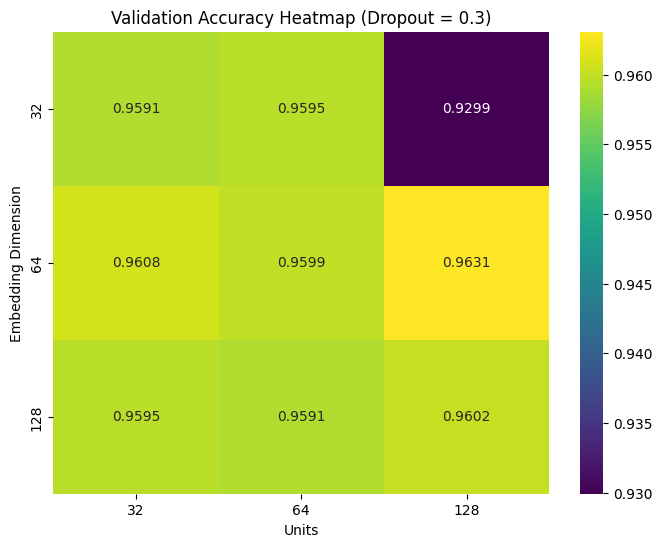


Retraining best model with Embed Dim: 64.0, Units: 128.0, Dropout: 0.3 for 15 epochs...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


350/350 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.9277 - loss: 0.2655 - val_accuracy: 0.9299 - val_loss: 0.2548
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.9299 - loss: 0.2589 - val_accuracy: 0.9299 - val_loss: 0.2547
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.9302 - loss: 0.2470 - val_accuracy: 0.9418 - val_loss: 0.1652
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.9593 - loss: 0.1212 - val_accuracy: 0.9599 - val_loss: 0.1225
Epoch 5/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.9783 - loss: 0.0666 - val_accuracy: 0.9604 - val_loss: 0.1361
Epoch 6/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9875 - loss: 0.0420 - val_accuracy: 0.9549 - val_loss: 0.1563
Epoch 7/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9920 - loss: 0.0277 - val_accuracy: 0.9570 - val_loss: 0.1832

Evaluating final best GRU model on test set...
Final Best GRU Model Test Accuracy: 0.9595
Final Be

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

embed_dims = [32, 64, 128]
units_list = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]

results = []

def build_gru_grid_search(embed_dim, units, dropout_rate, num_classes=NUM_CLASSES, max_vocab=MAX_VOCAB, max_len=MAX_LEN):
    model = Sequential([
        Embedding(input_dim=max_vocab, output_dim=embed_dim, input_length=max_len),
        GRU(units, dropout=dropout_rate, recurrent_dropout=dropout_rate),
        Dropout(dropout_rate),
        Dense(num_classes, activation='softmax')
    ])
    model = compile_model(model)
    return model

print("Starting Grid Search...")
for ed in embed_dims:
    for ul in units_list:
        for dr in dropout_list:
            print(f"\nTraining GRU with Embed Dim: {ed}, Units: {ul}, Dropout: {dr}")
            model = build_gru_grid_search(embed_dim=ed, units=ul, dropout_rate=dr)


            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=5,
                batch_size=BATCH_SIZE,
                verbose=0
            )

            val_acc = max(history.history['val_accuracy'])
            results.append({
                'embed_dim': ed,
                'units': ul,
                'dropout_rate': dr,
                'val_accuracy': val_acc
            })

print("Grid Search Complete.")

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='val_accuracy', ascending=False)

print("\nTop 3 best hyperparameter combinations:")
print(results_df_sorted.head(3))

fixed_dropout_results = results_df[results_df['dropout_rate'] == 0.3]
heatmap_data = fixed_dropout_results.pivot(index='embed_dim', columns='units', values='val_accuracy')

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".4f")
plt.title('Validation Accuracy Heatmap (Dropout = 0.3)')
plt.xlabel('Units')
plt.ylabel('Embedding Dimension')
plt.show()

best_params = results_df_sorted.iloc[0]
print(f"\nRetraining best model with Embed Dim: {best_params['embed_dim']}, Units: {best_params['units']}, Dropout: {best_params['dropout_rate']} for 15 epochs...")

final_best_gru_model = build_gru_grid_search(
    embed_dim=int(best_params['embed_dim']),
    units=int(best_params['units']),
    dropout_rate=float(best_params['dropout_rate'])
)

final_hist = final_best_gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("final_best_gru_model"),
    verbose=1
)
print("\nEvaluating final best GRU model on test set...")
loss, accuracy = final_best_gru_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Best GRU Model Test Accuracy: {accuracy:.4f}")
print(f"Final Best GRU Model Test Loss: {loss:.4f}")